# Study 01 — Exploratory Data Analysis (EDA)

## Has Morocco's Minimum Wage Protected Workers Against Inflation Since 2000?

### Morocco Economic Intelligence Lab (MEIL)

---

## Objective

This notebook explores the dataset generated during the feature engineering phase.

The objective is to understand the behaviour of the variables before conducting the economic analysis.

---

## Exploratory Tasks

- Dataset overview
- Distribution analysis
- Time-series visualization
- Correlation analysis
- Annual growth comparison
- Purchasing power dynamics

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

## Project Configuration

In [2]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

INPUT_FILE = PROCESSED_DATA / "smig_cpi_features.csv"

df = pd.read_csv(INPUT_FILE)

df.head()

,year,cpi,smig_monthly,SMIG_Index,CPI_Index,Inflation_Rate,Nominal_Wage_Growth,Real_Wage_Index,Real_Wage_Growth,Purchasing_Power_Gap,PPPR,Cumulative_Inflation,Cumulative_Wage_Growth
0,2000,83.649753,1826,100.000000,100.000000,NaN,NaN,100.000000,NaN,NaN,1.000000,0.000000,0.000000
1,2001,84.168216,1826,100.000000,100.619802,0.619802,0.000000,99.384016,-0.619802,-0.619802,0.993840,0.619802,0.000000
2,2002,86.521239,1826,100.000000,103.432749,2.795620,0.000000,96.681178,-2.795620,-2.795620,0.966812,3.432749,0.000000
3,2003,87.531577,1826,100.000000,104.640568,1.167734,0.000000,95.565231,-1.167734,-1.167734,0.955652,4.640568,0.000000
4,2004,88.838812,1845,101.040526,106.203316,1.493444,1.040526,95.138767,-0.452918,-0.452918,0.951388,6.203316,1.040526


## Dataset Overview

In [3]:
print("="*70)
print("DATASET OVERVIEW")
print("="*70)

print()

print(f"Observations : {len(df)}")
print(f"Variables    : {len(df.columns)}")

print()

df.info()

DATASET OVERVIEW

Observations : 25
Variables    : 13

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    25 non-null     int64  
 1   cpi                     25 non-null     float64
 2   smig_monthly            25 non-null     int64  
 3   SMIG_Index              25 non-null     float64
 4   CPI_Index               25 non-null     float64
 5   Inflation_Rate          24 non-null     float64
 6   Nominal_Wage_Growth     24 non-null     float64
 7   Real_Wage_Index         25 non-null     float64
 8   Real_Wage_Growth        24 non-null     float64
 9   Purchasing_Power_Gap    24 non-null     float64
 10  PPPR                    25 non-null     float64
 11  Cumulative_Inflation    25 non-null     float64
 12  Cumulative_Wage_Growth  25 non-null     float64
dtypes: float64(11), int64(2)
memory usage: 2.7 KB


## Descriptive Statistics

In [4]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
year,25.0,2012.00,7.36,2000.00,2006.00,2012.00,2018.00,2024.00
cpi,25.0,102.62,12.75,83.65,92.66,102.21,110.73,129.60
smig_monthly,25.0,2315.00,447.35,1826.00,1845.00,2337.00,2570.00,3111.00
SMIG_Index,25.0,126.78,24.50,100.00,101.04,127.98,140.74,170.37
CPI_Index,25.0,122.68,15.24,100.00,110.77,122.18,132.38,154.94
Inflation_Rate,24.0,1.85,1.63,0.30,0.96,1.34,1.92,6.66
Nominal_Wage_Growth,24.0,2.28,2.86,0.00,0.00,0.00,4.85,9.94
Real_Wage_Index,25.0,102.60,8.27,89.39,95.14,102.81,109.96,115.87
Real_Wage_Growth,24.0,0.43,3.09,-3.28,-1.64,-0.98,3.21,9.03
Purchasing_Power_Gap,24.0,0.43,3.09,-3.28,-1.64,-0.98,3.21,9.03


## Correlation Matrix

In [5]:
correlation = df.select_dtypes(include=np.number).corr()

correlation.round(3)

,year,cpi,smig_monthly,SMIG_Index,CPI_Index,Inflation_Rate,Nominal_Wage_Growth,Real_Wage_Index,Real_Wage_Growth,Purchasing_Power_Gap,PPPR,Cumulative_Inflation,Cumulative_Wage_Growth
year,1.000,0.977,0.974,0.974,0.977,0.217,0.257,0.822,0.124,0.124,0.822,0.977,0.974
cpi,0.977,1.000,0.964,0.964,1.000,0.324,0.258,0.756,0.068,0.068,0.756,1.000,0.964
smig_monthly,0.974,0.964,1.000,1.000,0.964,0.236,0.265,0.902,0.121,0.121,0.902,0.964,1.000
SMIG_Index,0.974,0.964,1.000,1.000,0.964,0.236,0.265,0.902,0.121,0.121,0.902,0.964,1.000
CPI_Index,0.977,1.000,0.964,0.964,1.000,0.324,0.258,0.756,0.068,0.068,0.756,1.000,0.964
Inflation_Rate,0.217,0.324,0.236,0.236,0.324,1.000,0.137,0.042,-0.400,-0.400,0.042,0.324,0.236
Nominal_Wage_Growth,0.257,0.258,0.265,0.265,0.258,0.137,1.000,0.257,0.853,0.853,0.257,0.258,0.265
Real_Wage_Index,0.822,0.756,0.902,0.902,0.756,0.042,0.257,1.000,0.216,0.216,1.000,0.756,0.902
Real_Wage_Growth,0.124,0.068,0.121,0.121,0.068,-0.400,0.853,0.216,1.000,1.000,0.216,0.068,0.121
Purchasing_Power_Gap,0.124,0.068,0.121,0.121,0.068,-0.400,0.853,0.216,1.000,1.000,0.216,0.068,0.121


## Evolution of CPI and Monthly SMIG

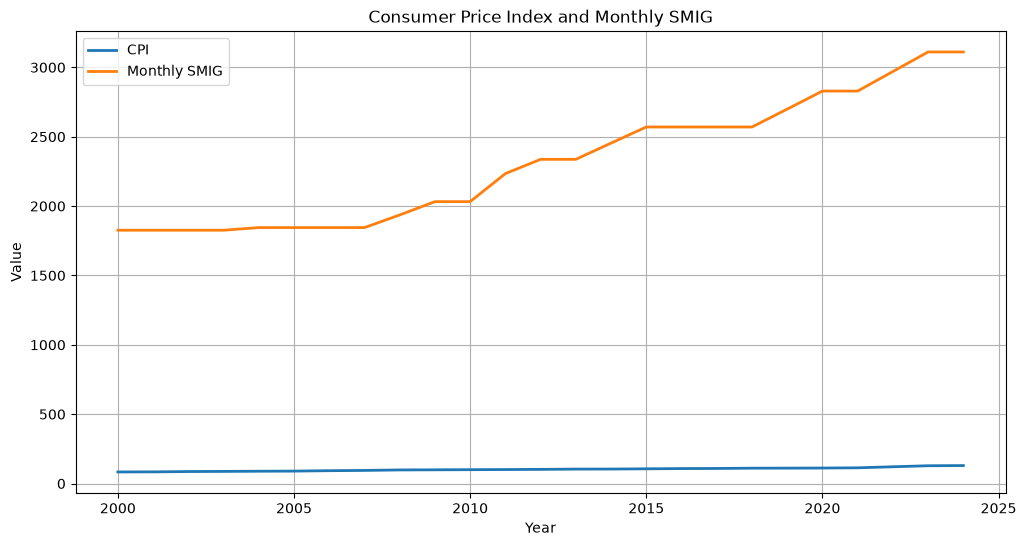

In [6]:
plt.figure(figsize=(12,6))

plt.plot(df["year"], df["cpi"], linewidth=2, label="CPI")

plt.plot(df["year"], df["smig_monthly"], linewidth=2, label="Monthly SMIG")

plt.title("Consumer Price Index and Monthly SMIG")

plt.xlabel("Year")

plt.ylabel("Value")

plt.grid(True)

plt.legend()

plt.show()

## Indexed Evolution (Base 100)

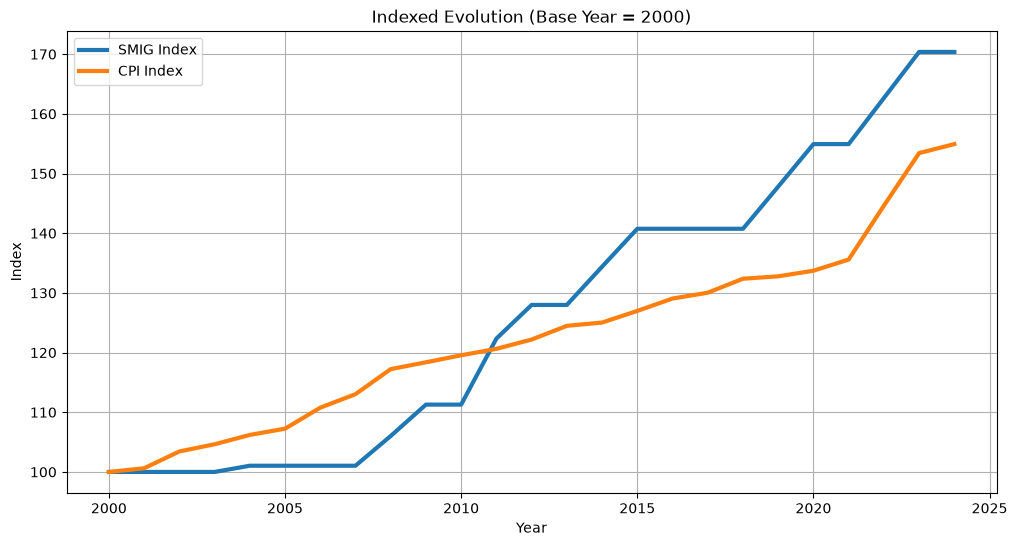

In [7]:
plt.figure(figsize=(12,6))

plt.plot(df["year"], df["SMIG_Index"], linewidth=3, label="SMIG Index")

plt.plot(df["year"], df["CPI_Index"], linewidth=3, label="CPI Index")

plt.title("Indexed Evolution (Base Year = 2000)")

plt.xlabel("Year")

plt.ylabel("Index")

plt.grid(True)

plt.legend()

plt.show()

## Annual Inflation Rate

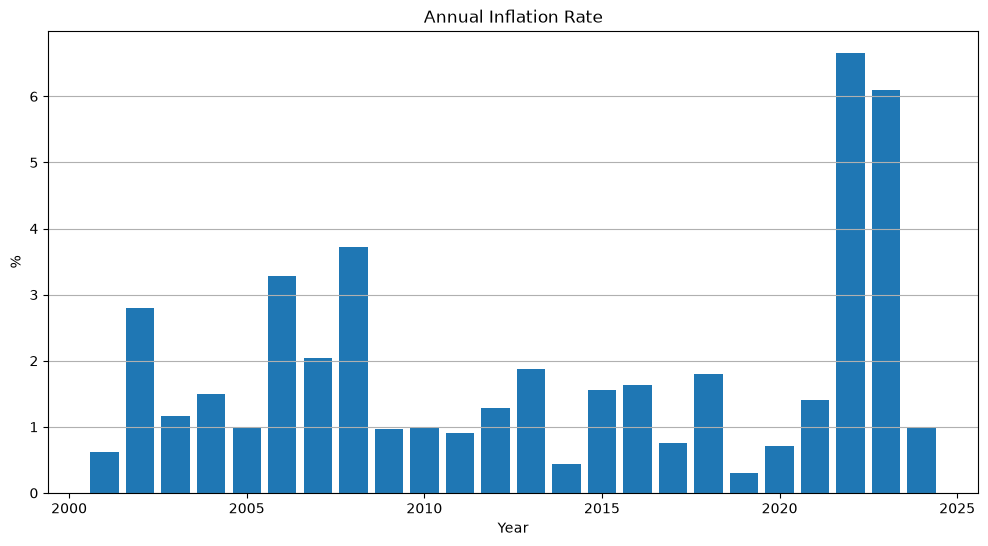

In [8]:
plt.figure(figsize=(12,6))

plt.bar(df["year"], df["Inflation_Rate"])

plt.title("Annual Inflation Rate")

plt.xlabel("Year")

plt.ylabel("%")

plt.grid(axis="y")

plt.show()

## Nominal Wage Growth

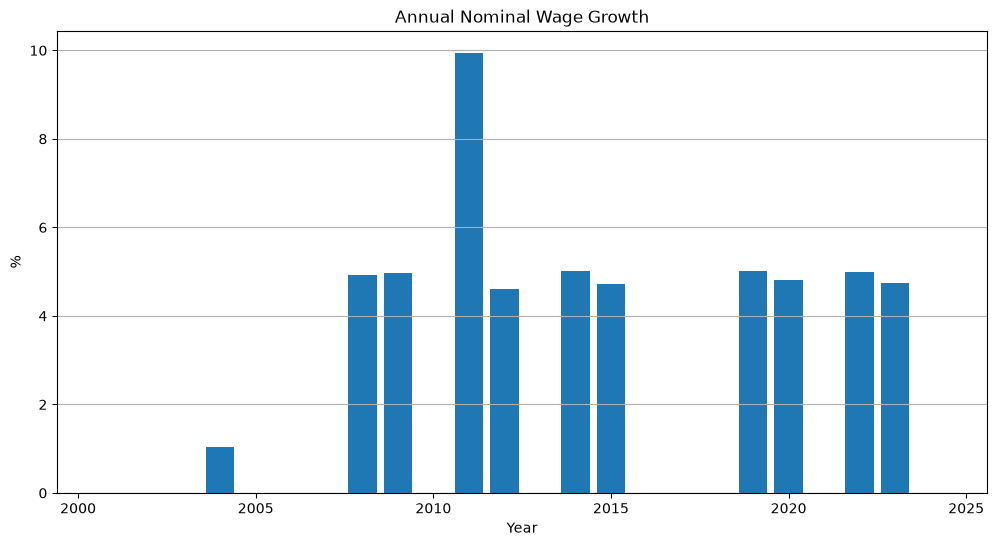

In [9]:
plt.figure(figsize=(12,6))

plt.bar(df["year"], df["Nominal_Wage_Growth"])

plt.title("Annual Nominal Wage Growth")

plt.xlabel("Year")

plt.ylabel("%")

plt.grid(axis="y")

plt.show()

## Real Wage Index

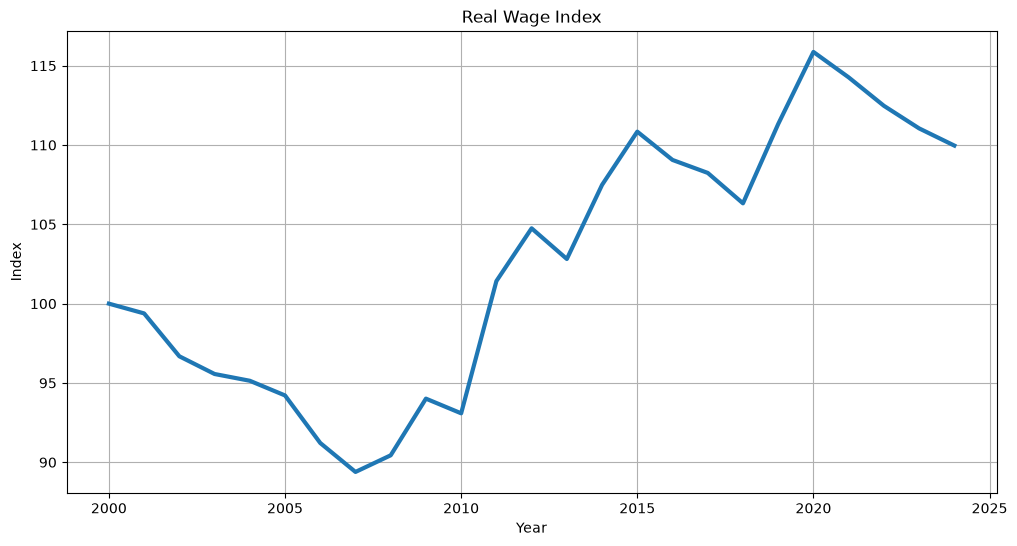

In [10]:
plt.figure(figsize=(12,6))

plt.plot(df["year"], df["Real_Wage_Index"], linewidth=3)

plt.title("Real Wage Index")

plt.xlabel("Year")

plt.ylabel("Index")

plt.grid(True)

plt.show()

## Purchasing Power Gap

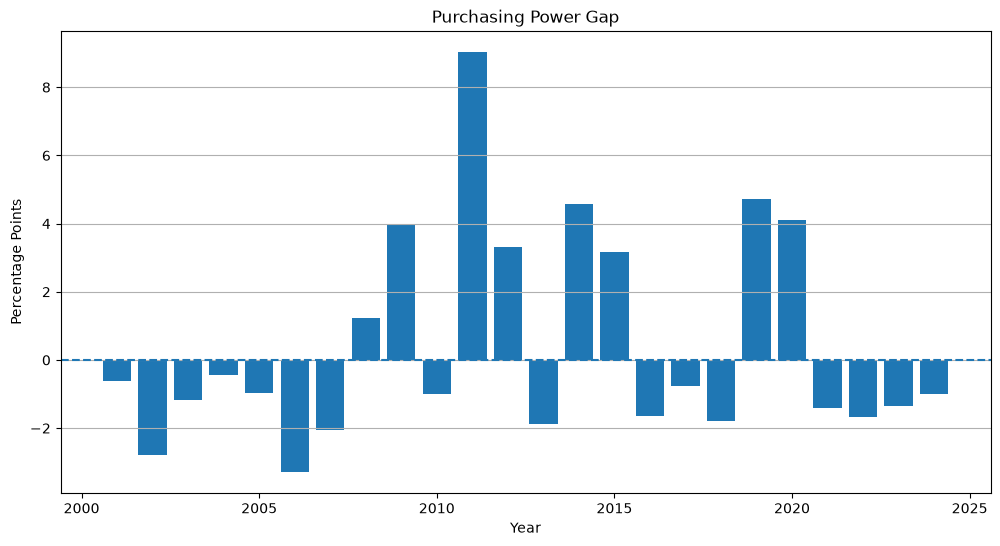

In [11]:
plt.figure(figsize=(12,6))

plt.bar(df["year"], df["Purchasing_Power_Gap"])

plt.axhline(0, linestyle="--")

plt.title("Purchasing Power Gap")

plt.xlabel("Year")

plt.ylabel("Percentage Points")

plt.grid(axis="y")

plt.show()

## Purchasing Power Protection Ratio (PPPR)

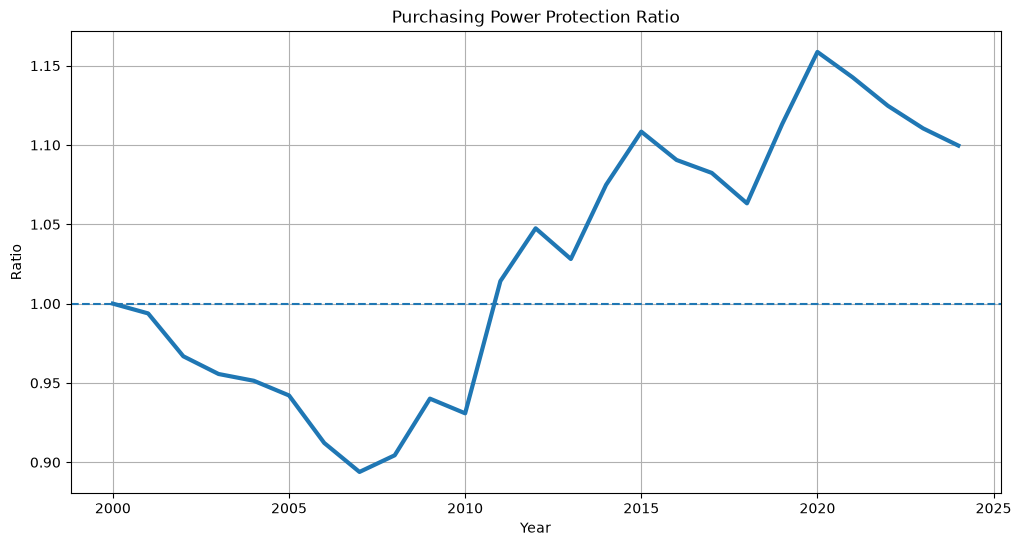

In [12]:
plt.figure(figsize=(12,6))

plt.plot(df["year"], df["PPPR"], linewidth=3)

plt.axhline(1, linestyle="--")

plt.title("Purchasing Power Protection Ratio")

plt.xlabel("Year")

plt.ylabel("Ratio")

plt.grid(True)

plt.show()

## Distribution of Annual Inflation

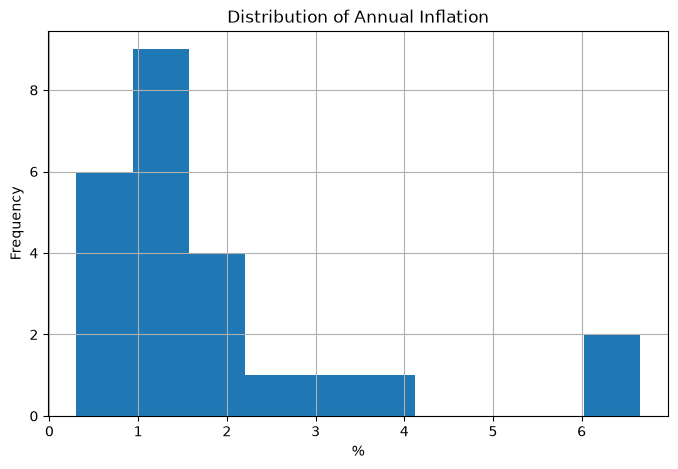

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["Inflation_Rate"].dropna(), bins=10)

plt.title("Distribution of Annual Inflation")

plt.xlabel("%")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

## Distribution of Nominal Wage Growth

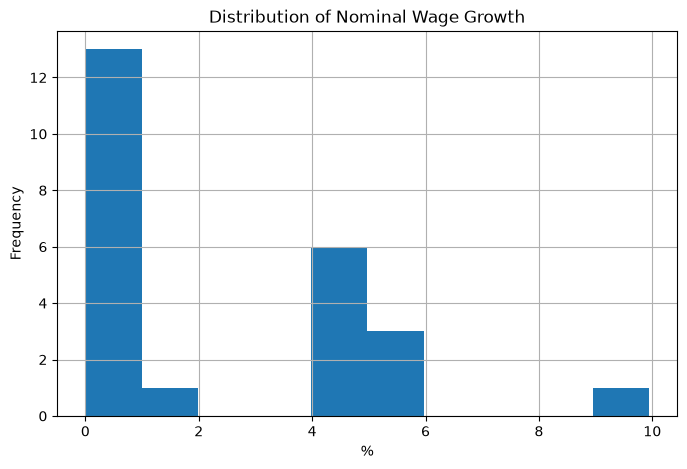

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["Nominal_Wage_Growth"].dropna(), bins=10)

plt.title("Distribution of Nominal Wage Growth")

plt.xlabel("%")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

## Final Exploratory Summary

In [15]:
print("="*70)
print("EXPLORATORY DATA ANALYSIS COMPLETED")
print("="*70)

print()

print(f"Study period           : {df['year'].min()} - {df['year'].max()}")

print(f"Average inflation      : {df['Inflation_Rate'].mean():.2f}%")

print(f"Average wage growth    : {df['Nominal_Wage_Growth'].mean():.2f}%")

print(f"Average PPPR           : {df['PPPR'].mean():.3f}")

print(f"Maximum inflation      : {df['Inflation_Rate'].max():.2f}%")

print(f"Maximum wage growth    : {df['Nominal_Wage_Growth'].max():.2f}%")

print()

print("Exploratory analysis successfully completed.")

EXPLORATORY DATA ANALYSIS COMPLETED

Study period           : 2000 - 2024
Average inflation      : 1.85%
Average wage growth    : 2.28%
Average PPPR           : 1.026
Maximum inflation      : 6.66%
Maximum wage growth    : 9.94%

Exploratory analysis successfully completed.
